In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris (1).xlsx to iris (1).xlsx
Saving letter-recognition.xlsx to letter-recognition.xlsx


In [2]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

linear_cm = confusion_matrix(y_test, y_pred_linear)

print("Linear Kernel SVM")
print("Accuracy:", linear_accuracy)
print("Confusion Matrix:")
print(linear_cm)

rbf_svm = SVC(kernel='rbf')

rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

rbf_cm = confusion_matrix(y_test, y_pred_rbf)

print("\nRBF Kernel SVM")
print("Accuracy:", rbf_accuracy)
print("Confusion Matrix:")
print(rbf_cm)

Linear Kernel SVM
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel SVM
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy: 0.99675
Confusion Matrix:
[[3851    0]
 [  13  136]]
AUC Score: 0.9998832343730122


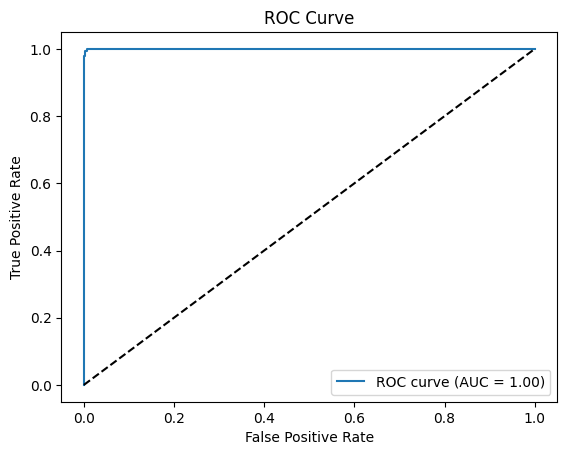

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

df = pd.read_excel("letter-recognition.xlsx")

X = df.drop("letter", axis=1)
y = df["letter"]

y = (y == 'A').astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()